# Extract Single-cell features with patch-level feature extractor

**Goal**: since we have some foundational feature extractors that are tailed for H&E (ex: Phikon-v2), we want to use them to extract features. However, they are trained on patches instead of single-cell. But for our purposes, we want single-cell features since that's the way we can resolve the resolution issue between PCM and H&E.

To do this, we want to leverage both the *attention map* and *output embedding* to generate features for single cell

We will first test this on PanNuke dataset for classifying single nuclei to see if the single-cell features generated this way is truly representative

Also, we can use the masks provided to quantify the "segmentation" quality.

In [ ]:
'''
get PanNuke images from fold 1 and masks from fold 1, just for testing
The PanNuke dataset is stored in two numpy files:
- masks/fold1/images.npy: size (N, 256, 256, 3)
- images/fold1/masks.npy: size (N, 256, 256, 6), where each channel is the mask for one class
'''

from torch.utils.data import Dataset
import os
import numpy as np

class PanNukeDataset(Dataset):
    def __init__(self, root_dir):
        self.images = np.load(os.path.join(root_dir, 'images/fold1/images.npy'))
        self.masks = np.load(os.path.join(root_dir, 'masks/fold1/masks.npy'))
        self.type = np.load(os.path.join(root_dir, 'images/fold1/types.npy'))
    def __len__(self):
        return len(self.images)
    def __getitem__(self, idx):
        return self.images[idx], self.masks[idx], self.type[idx]

In [4]:
'''
Load the PanNuke dataset
'''
data = PanNukeDataset('/Users/ric/Downloads/Fold 1')
print(len(data))
print(data[0][0].shape)
print(data[0][1].shape)

2656
(256, 256, 3)
(256, 256, 6)


In [233]:
'''prep the feature extractor'''

import torchvision.transforms.v2 as v2
import torch

def owkin_features(model, device, image_processor, x, return_attn = False):
    model.to(device)
    model.eval()
    with torch.no_grad():
        x = x.to(device)
        todytpe = v2.ToDtype(torch.float32, scale=True)
        x = todytpe(x)
        x = torch.clamp(x, max=1, min=0) #correct for float overflow
        inputs = image_processor(x, return_tensors="pt", do_rescale=False)
        outputs = model(**inputs.to(device),output_attentions=return_attn)
        extracted = outputs.last_hidden_state#[:, 0, :]
    # return last layer attention and full embedding
    # shape of attention is (batch_size, num_heads, seq_length, seq_length)
    # shape of extracted is (batch_size, seq_length, hidden_size)
    if return_attn: 
        return outputs.attentions[-1], extracted
    else:
        return extracted

def get_attn_features(extractor, processor, x):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    # convert x to tensor
    x = torch.tensor(x).permute(2, 0, 1).unsqueeze(0)
    # get attention and features
    attention, features = owkin_features(extractor, device, processor, x, return_attn=True)
    return attention, features


In [215]:
'''
Visualize the attention map
'''

import matplotlib.pyplot as plt

def generate_attn_maps(attn: torch.Tensor, size: int = 256, 
                       threshold: float = 0.6) -> np.ndarray:
    '''
    Process the attention values to generate a heatmap of size x size based on threshold
    '''
    # get the attention except for the cls token
    class_token_attention = attn[:, :, 0, 1:]
    nh = class_token_attention.shape[1]
    # we keep only a certain percentage of the mass according to threshold
    val, idx = torch.sort(class_token_attention.reshape(nh, -1))
    val /= torch.sum(val, dim=1, keepdim=True)
    cumval = torch.cumsum(val, dim=1)
    th_attn = cumval > (1 - threshold)
    idx2 = torch.argsort(idx)
    for head in range(class_token_attention.shape[1]):
        th_attn[head] = th_attn[head][idx2[head]]
    num_patches_side = int(class_token_attention.shape[-1] ** 0.5)
    class_token_attention = th_attn.reshape(1, nh, num_patches_side, num_patches_side).float()
    # average all the head
    class_token_attention = class_token_attention.mean(dim=1)
    attention_map = class_token_attention.view(num_patches_side, num_patches_side).cpu()
    # extrapolate to size x size
    resized_attn = torch.nn.functional.interpolate(attention_map.unsqueeze(0).unsqueeze(0), size=(size, size), 
                                                        mode='bicubic')
    # return a numpy array of size x size (no batch or channel)
    return resized_attn.squeeze(0).squeeze(0).cpu().numpy()


# def generate_attn_maps(attn: torch.Tensor, size: int = 256, 
#                        threshold: float = 0.6) -> np.ndarray:
#     '''
#     Process the attention values to generate a heatmap of size x size based on threshold
#     '''
#     # get the attention except for the cls token
#     class_token_attention = attn[:, :, 0, 1:]
#     # normalize the attention
#     class_token_attention = class_token_attention / class_token_attention.sum(dim=-1, keepdim=True)
#     # get the mean of the attention by head
#     class_token_attention = class_token_attention.mean(dim=1)
#     # keep only the top threshold values
#     thres_value = torch.quantile(class_token_attention, threshold, dim=1, keepdim=True)
#     class_token_attention[class_token_attention < thres_value] = 0
#     num_patches_side = int(class_token_attention.shape[-1] ** 0.5)
#     class_token_attention = class_token_attention.reshape(-1, num_patches_side, num_patches_side).float()
#     # extrapolate to size x size
#     resized_attn = torch.nn.functional.interpolate(class_token_attention.unsqueeze(0), size=(size, size), 
#                                                         mode='bicubic')
#     # return a numpy array of size x size (no batch or channel)
#     return resized_attn.squeeze(0).squeeze(0).cpu().numpy()

In [234]:
image_num = 1000

In [235]:
'''
Extract features from the first image
'''
from transformers import AutoImageProcessor, AutoModel
# feature_extractor = AutoModel.from_pretrained("/fs01/home/richarddong/.cache/huggingface/hub/phikon-v2")

image = data[image_num][0]

feature_extractor = AutoModel.from_pretrained("owkin/phikon-v2")
image_processor = AutoImageProcessor.from_pretrained("owkin/phikon-v2")
attention, features = get_attn_features(feature_extractor, image_processor, image)
print(attention)


tensor([[[[0.0170, 0.0090, 0.0074,  ..., 0.0050, 0.0055, 0.0066],
          [0.0993, 0.0092, 0.0071,  ..., 0.0029, 0.0033, 0.0039],
          [0.0988, 0.0094, 0.0070,  ..., 0.0030, 0.0035, 0.0042],
          ...,
          [0.0746, 0.0113, 0.0083,  ..., 0.0040, 0.0049, 0.0062],
          [0.0787, 0.0111, 0.0081,  ..., 0.0039, 0.0047, 0.0060],
          [0.0822, 0.0108, 0.0081,  ..., 0.0037, 0.0045, 0.0055]],

         [[0.0434, 0.0131, 0.0089,  ..., 0.0045, 0.0053, 0.0071],
          [0.0371, 0.0108, 0.0075,  ..., 0.0049, 0.0054, 0.0064],
          [0.0347, 0.0103, 0.0072,  ..., 0.0050, 0.0055, 0.0063],
          ...,
          [0.0266, 0.0086, 0.0064,  ..., 0.0052, 0.0055, 0.0062],
          [0.0280, 0.0087, 0.0064,  ..., 0.0050, 0.0054, 0.0060],
          [0.0298, 0.0091, 0.0065,  ..., 0.0050, 0.0054, 0.0061]],

         [[0.2531, 0.0134, 0.0101,  ..., 0.0035, 0.0043, 0.0048],
          [0.1970, 0.0146, 0.0107,  ..., 0.0042, 0.0053, 0.0059],
          [0.1814, 0.0157, 0.0116,  ..., 0

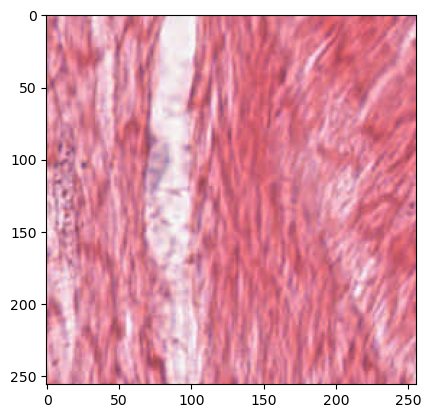

In [236]:
'''
Show the image 
'''
resized_attn = generate_attn_maps(attention, size=256)
# show
# normalize the image
plot_image = image / 255

# overlay the attention map
plt.imshow(plot_image)
plt.show()
plt.close()



-0.006823864 0.8732053


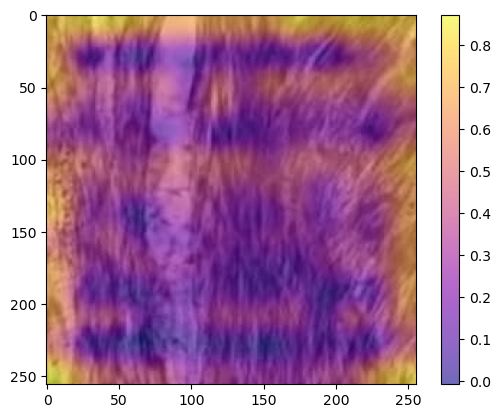

In [237]:
print(min(resized_attn.flatten()), max(resized_attn.flatten()))

# convert plot image to gray scale
gray_image = np.dot(plot_image[...,:3], [0.2989, 0.5870, 0.1140])

plt.imshow(gray_image, cmap='gray')
plt.imshow(resized_attn, alpha=0.6, cmap='plasma')
plt.colorbar()
plt.show()

In [149]:
'''Obtain the cell by using the plotted mask'''
print(resized_attn)


[[0.7617153  0.7616684  0.761642   ... 0.75548065 0.75550705 0.75555396]
 [0.7626199  0.76256937 0.76254094 ... 0.75590384 0.7559323  0.7559828 ]
 [0.7631267  0.76307416 0.7630447  ... 0.756141   0.7561705  0.756223  ]
 ...
 [0.8846621  0.8848752  0.8849945  ... 0.8148282  0.8150049  0.8153202 ]
 [0.88452697 0.8847501  0.8848751  ... 0.81473833 0.81490815 0.8152113 ]
 [0.8842857  0.8845269  0.88466215 ... 0.8145779  0.81473553 0.815017  ]]
